# Drift Chamber Geant4 Sim Data Analysis

In [363]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
import pandas as pd
import random
import uproot
from scipy.stats import chi2

from matplotlib.lines import Line2D
from matplotlib.patches import Annulus
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar

#%matplotlib widget

## Import Data

In [5]:
def organize_df(df, droplist):
    for name in droplist:
        
        # split formatted str to list of strs
        str_list = df[name].str.split('|').str[:-1]

        # convert strs to floats
        df[name] = str_list.apply(lambda x: [float(i) for i in x] if isinstance(x, list) else x)

    cols = df.filter(like=f"{droplist[0]}").columns        # get column with name droplist[0]
    nan_indices = df.index[~df[cols].notna().any(axis=1)]   # find indices with nan val

    df = df.drop(nan_indices)                               # drop row if it has nan val
    
    return df


In [5]:
# Get gas hit data
events_df = pd.read_csv(f'csv/hits/event_action_data.csv')
events_df = organize_df(events_df, ['energies', 'hitx', 'hity', 'hitz'])

# Get initial step data
steps_df = pd.read_csv(f'csv/hits/init_step_data.csv')

# Get multiple scattering data
eepos_df = pd.read_csv(f'csv/hits/entry_exit_data.csv')

In [6]:
def data_for_cylinder(r_outer, r_inner, res, height):
    theta = np.linspace(0, 2 * np.pi, res)
    z = np.linspace(-height, height, res)
    theta_grid, z_grid = np.meshgrid(theta, z)
    
    x_grid = r_outer * np.cos(theta_grid)
    y_grid = r_outer * np.sin(theta_grid)

    return x_grid, y_grid, z_grid

def get_circle(r, num):
    theta = np.linspace(0, 2*np.pi, num)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

## Energy loss

### Edep at hit positions

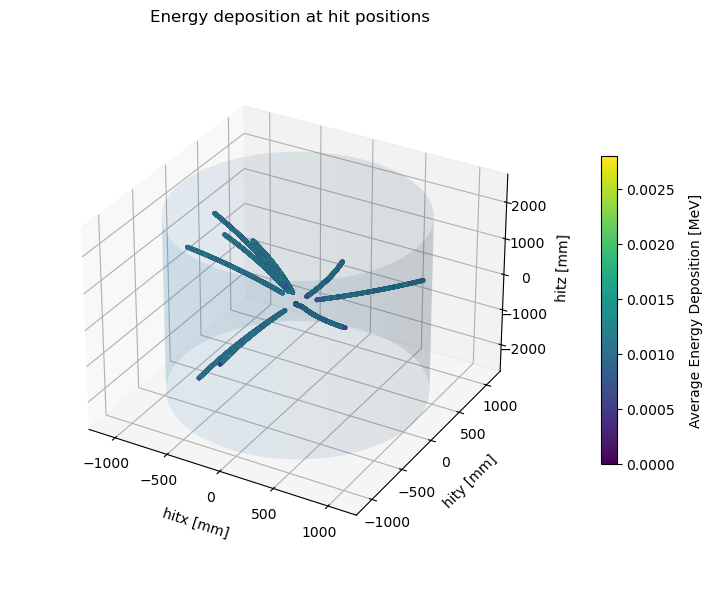

In [9]:
def plot_Edep_per_hit(df, num):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    hitx = []
    hity = []
    hitz = []
    energies = []
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)

    for i in range(0, num):
        try:       cur_row = df.iloc[i] 
        except:    continue
            
        energies += cur_row['energies']
    
    norm = mcolors.LogNorm(vmin=None, vmax=max(energies))
    cmap = plt.get_cmap("viridis")
    
    for i in range(0, num):
        try:      cur_row = df.loc[i]
        except:   continue

        hitx = cur_row['hitx']
        hity = cur_row['hity']
        hitz = cur_row['hitz']

        colours = cmap(norm(cur_row['energies']))
        ax.scatter(hitx, hity, hitz, c=colours, s=5.0)
    
    norm = mcolors.Normalize(vmin=min(energies), vmax=max(energies))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, shrink=0.5, pad=0.05)
    cbar.set_label("Average Energy Deposition [MeV]", labelpad=10)
    
    plt.title("Energy deposition at hit positions")
    ax.set_xlabel('hitx [mm]', labelpad=10)
    ax.set_ylabel('hity [mm]', labelpad=10)
    ax.set_zlabel('hitz [mm]', labelpad=10)


num_to_plot = 10
plot_Edep_per_hit(events_df, num_to_plot)

### Energy loss over distance

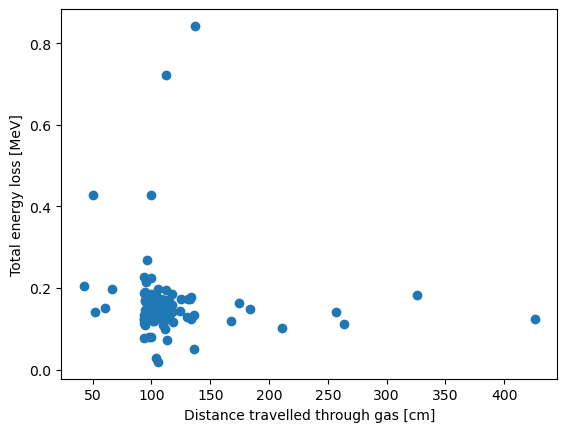

In [11]:
def plot_Eloss_over_dist(df1, df2):
    totE = []
    dist = []
    
    count = 0
    
    for i in range(len(events_df)):
        try:
            cur_event = df1.loc[i]
            cur_step = df2.loc[count]
        except:
            continue
    
        if not cur_event["num_hits"]: continue
        
        totE.append(sum([float(x) for x in cur_event['energies'][:-1]])) 
        dist.append(cur_step["tot_dist"])
        count += 1
    
    totE = np.array(totE)
    tot_dis = np.array(dist) * 0.1
    
    plt.scatter(tot_dis, totE)
    plt.xlabel("Distance travelled through gas [cm]")
    plt.ylabel("Total energy loss [MeV]")

    return tot_dis

tot_dis = plot_Eloss_over_dist(events_df, steps_df)

### dE/dx plot

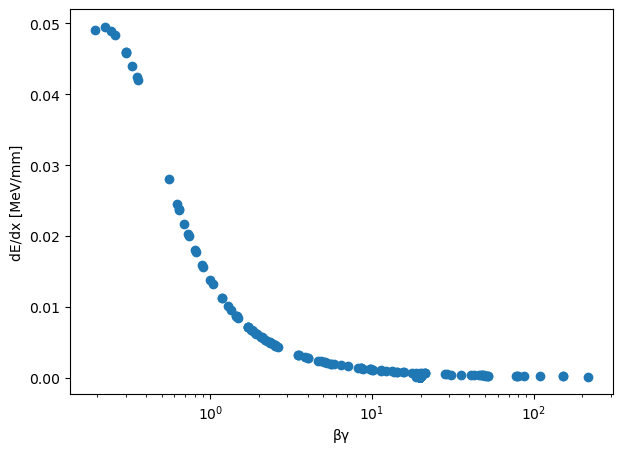

In [13]:
rest_mass = 105.6583715 #MeV
density =  4.75079e15 * 0.000001 #g /mm3

'''
fig2 = plt.figure(figsize=(7,5))
plt.scatter(steps_df["beta_gamma"], steps_df["dEdx"] / density)
plt.xlabel("βγ")
plt.ylabel("dE/dx [MeV mm$^2$/g]")
#'''

def plot_dEdx(df):
    fig = plt.figure(figsize=(7,5))
    plt.scatter(df["beta_gamma"], df["dEdx"])
    plt.xlabel("βγ")
    plt.ylabel("dE/dx [MeV/mm]")
    
    plt.xscale('log')

plot_dEdx(steps_df)

## Energy deposition in gas layers

### Import data

In [16]:
# Get gas layer data
layer_df = pd.read_csv(f'csv/layered/layered_edep_data.csv')
layer_df = organize_df(layer_df, ["entry_x", "entry_y", "entry_z", "exit_x", "exit_y", "exit_z", "edep"])

# Get radii of gas layers
radii_df = pd.read_csv(f'csv/layered/layer_radius.csv')

# Get initial step data
layered_steps_df = pd.read_csv(f'csv/layered/init_step_data.csv')

# Get gas hit data
layered_events_df = pd.read_csv(f'csv/layered/event_action_data_layered.csv')
layered_events_df = organize_df(layered_events_df, ['energies', 'hitx', 'hity', 'hitz'])


### Check previous plots

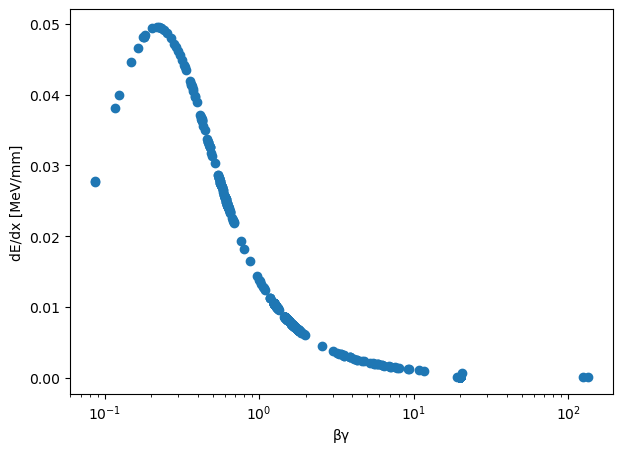

In [18]:
plot_dEdx(layered_steps_df)

### 3D plot of edep for n beams

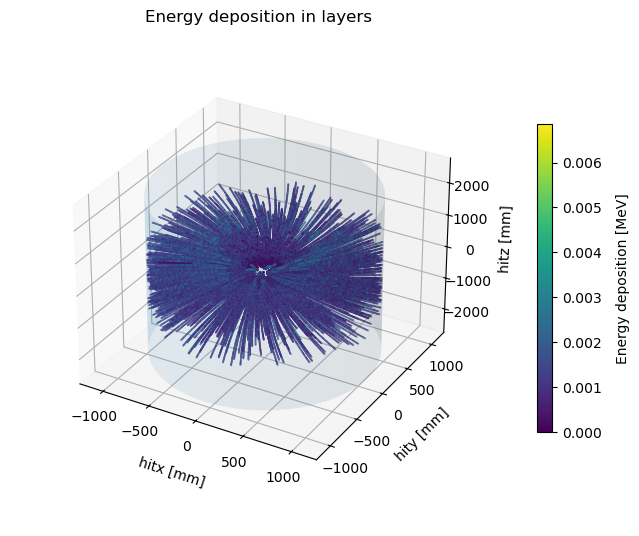

In [20]:
def plot_layered_beams(df, n):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)

    x = []
    y = []
    z = []
    edep = []
    
    for i in range(0, n):
        try:     cur_df = df.loc[i]
        except:  continue

        #FIX THIS PROBLEM!!!
        cur_x = cur_df["entry_x"]
        cur_edep = cur_df["edep"]
        min_len = len(cur_x) - len(cur_edep)
        
        x += cur_x
        y += cur_df["entry_y"]
        z += cur_df["entry_z"]

        if min_len:
            edep += cur_edep[:-min_len]
        else:
            edep += cur_edep[:]
            
    img = ax.scatter(x, y, z, s=0.1, c=edep, cmap='viridis', alpha=1.0)
        
    cbar = fig.colorbar(img, ax=ax, shrink=0.5, pad=0.05)
    cbar.set_label("Energy deposition [MeV]", labelpad=10)

    plt.title("Energy deposition in layers")
    ax.set_xlabel('hitx [mm]', labelpad=10)
    ax.set_ylabel('hity [mm]', labelpad=10)
    ax.set_zlabel('hitz [mm]', labelpad=10)

num_to_plot = 1000
plot_layered_beams(layer_df, num_to_plot)

### 2D circular edep

In [22]:
def get_avg_edep_in_layer(r_inner, r_outer, df):
    tot_edep = 0
    count = 0

    # iterate through the dataframe rows
    for idx, cur_df in df.iterrows():
        energies = cur_df["edep"]

        is_edep = False

        #look at energies list for each row
        for j in range(len(energies)):
            entry_r = np.sqrt( cur_df["entry_x"][j] ** 2 + cur_df["entry_y"][j] ** 2 )
            exit_r = np.sqrt( cur_df["exit_x"][j] ** 2 + cur_df["exit_y"][j] ** 2 )
            
            if entry_r > r_inner and exit_r < r_outer:
                tot_edep += energies[j]
                is_edep = True

        if is_edep: count += 1
                
    return tot_edep / count if count > 0 else 0

def plot_layer_overview(rad_df, df, r_list):
    fig, ax = plt.subplots(figsize=(8, 8))
    energies = []

    for idx, row in rad_df.iterrows():
        energies.append(get_avg_edep_in_layer(row["r1"], row["r2"], df))

    norm = mcolors.Normalize(vmin=min(energies), vmax=max(energies))
    cmap = plt.get_cmap("viridis")

    for idx, row in rad_df.iterrows():
        r1 = row["r1"]
        r2 = row["r2"]
        colour = cmap(norm(energies[idx]))
        ring = Annulus(xy=(0, 0), r=r2, width=r2 - r1, facecolor=colour)
        ring.set_antialiased(False)
        ax.add_patch(ring)

    max_r = rad_df["r2"].max()
    ax.set_xlim(-(max_r + 100), max_r + 100)
    ax.set_ylim(-(max_r + 100), max_r + 100)
    ax.set_aspect("equal")

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]") 
    ax.set_title("Average energy deposition in gas layers")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, shrink=0.5, pad=0.05)
    cbar.set_label("Average Energy Deposition [MeV]", labelpad=10)

    if len(r_list):
        for radius in r_list:
            circle_x, circle_y = get_circle(radius, 1000)
            ax.plot(circle_x, circle_y, color="red", lw=1.0)

    return energies

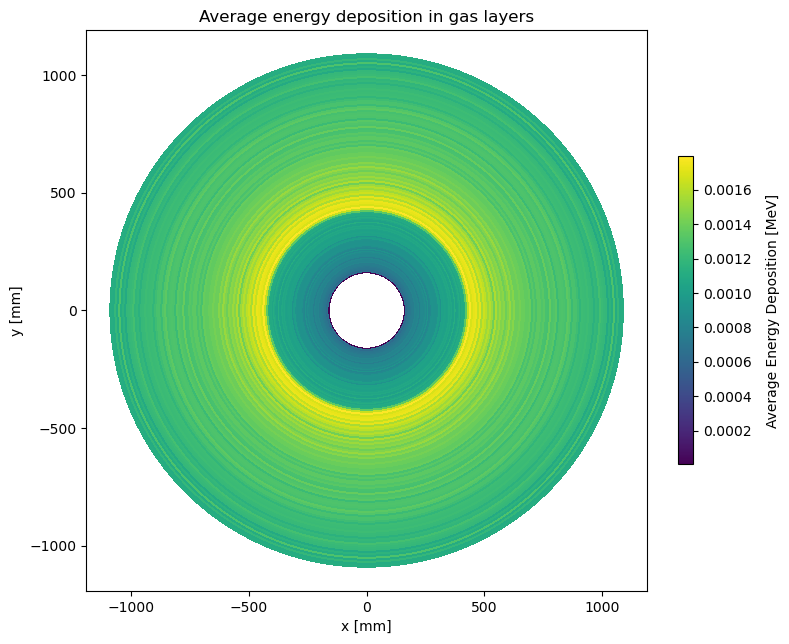

In [23]:
energies = plot_layer_overview(radii_df, layer_df, [])

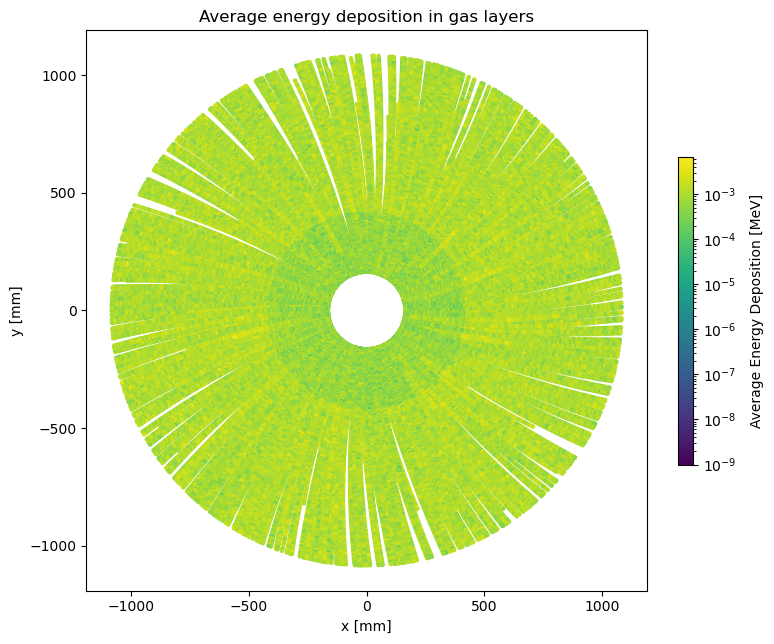

In [24]:
def plot_edep_layer_overview(df):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    edep = []
    for i in range(0, len(df)):
        try:  cur_df = df.iloc[i]
        except: continue
        
        edep.extend(cur_df["edep"]) 
        
    edep = np.array(edep)
    
    vmin_val = max(1e-9, edep.min()) 
    vmax_val = edep.max()
    norm = mcolors.LogNorm(vmin=vmin_val, vmax=vmax_val)
    cmap = plt.get_cmap("viridis")
    
    for i in range(0, len(df)):
        try:       cur_df = df.iloc[i]
        except:    continue
            
        colours = cmap(norm(cur_df["edep"]))
        ax.scatter(cur_df["entry_x"], cur_df["entry_y"], s=5.0, c=colours)
        
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, shrink=0.5, pad=0.05)
    cbar.set_label("Average Energy Deposition [MeV]", labelpad=10) 
    
    ax.set_aspect("equal")
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title("Average energy deposition in gas layers")

plot_edep_layer_overview(layer_df)

### Average edep histograms

Text(0.5, 0, 'Average energy deposition [MeV]')

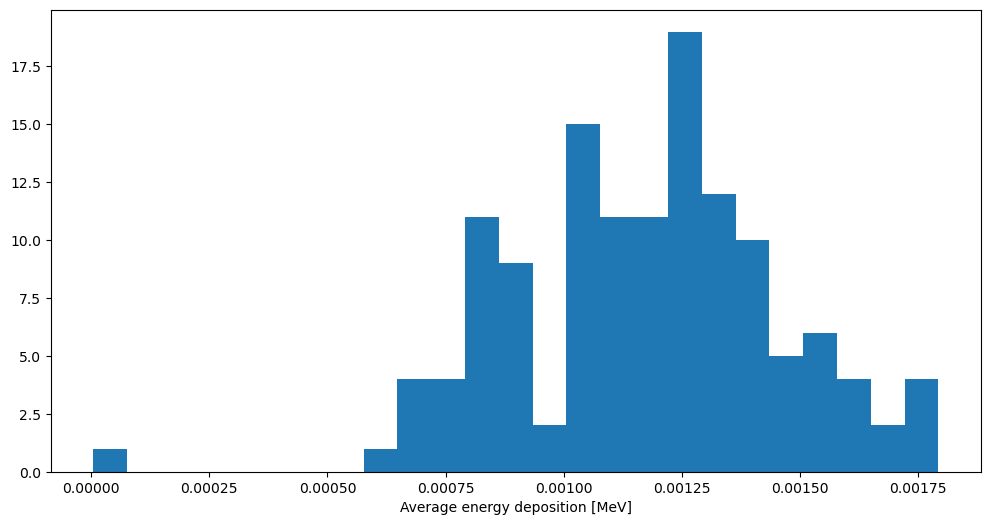

In [26]:
plt.figure(figsize=(12,6))
plt.hist(energies, bins=25)
plt.xlabel("Average energy deposition [MeV]")

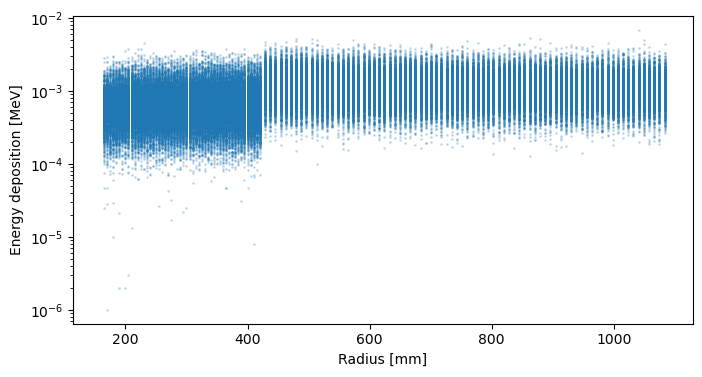

In [27]:
r_vals = []
e_vals = []

for _, cur_df in layer_df.iterrows():
    for j in range(len(cur_df["edep"])):
        r = np.hypot(cur_df["entry_x"][j], cur_df["entry_y"][j])
        r_vals.append(r)
        e_vals.append(cur_df["edep"][j])

plt.figure(figsize=(8,4))
plt.scatter(r_vals, e_vals, s=1, alpha=0.2)
plt.xlabel("Radius [mm]")
plt.ylabel("Energy deposition [MeV]")
plt.yscale("log")
plt.show()

### Random track

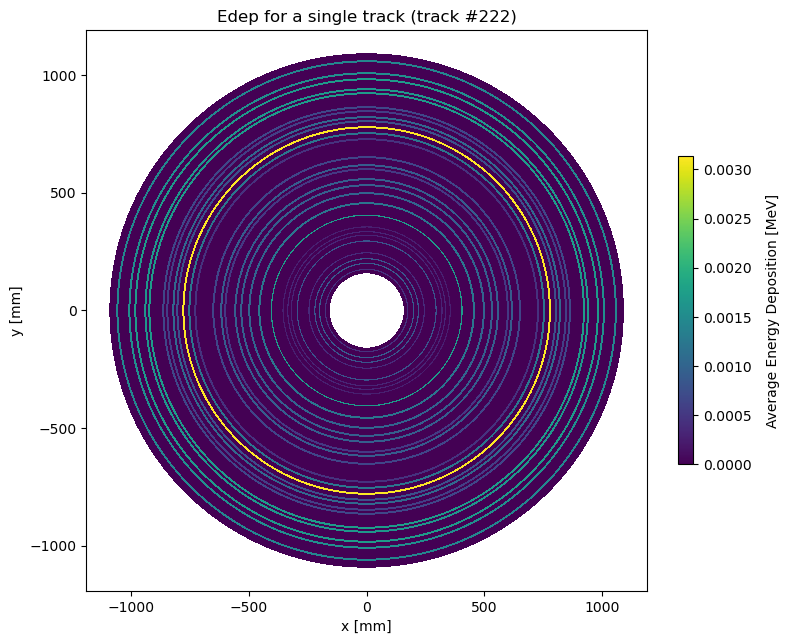

In [29]:
def get_edep_in_layer(r_inner, r_outer, df, ran_num):
    tot_edep = 0
    count = 0

    cur_df = df.iloc[ran_num]
    energies = cur_df["edep"]
        
    for j in range(len(energies)):
        entry_r = np.sqrt( cur_df["entry_x"][j] ** 2 + cur_df["entry_y"][j] ** 2 )
        exit_r = np.sqrt( cur_df["exit_x"][j] ** 2 + cur_df["exit_y"][j] ** 2 )
            
        if entry_r > r_inner and exit_r < r_outer:
            tot_edep += energies[j]
            count += 1
                
    return tot_edep / count if count > 0 else 0

def plot_onetrack_layer(rad_df, df, ran_num):
    fig, ax = plt.subplots(figsize=(8, 8))
    energies = []

    for idx, row in rad_df.iterrows():
        energies.append(get_edep_in_layer(row["r1"], row["r2"], df, ran_num))

    norm = mcolors.Normalize(vmin=min(energies), vmax=max(energies))
    cmap = plt.get_cmap("viridis")

    for idx, row in rad_df.iterrows():
        r1 = row["r1"]
        r2 = row["r2"]
        colour = cmap(norm(energies[idx]))
        ring = Annulus(xy=(0, 0), r=r2, width=r2 - r1, facecolor=colour)
        ring.set_antialiased(False)
        ax.add_patch(ring)

    max_r = rad_df["r2"].max()
    ax.set_xlim(-(max_r + 100), max_r + 100)
    ax.set_ylim(-(max_r + 100), max_r + 100)
    ax.set_aspect("equal")

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]") 
    ax.set_title(f"Edep for a single track (track #{ran_num})")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, shrink=0.5, pad=0.05)
    cbar.set_label("Average Energy Deposition [MeV]", labelpad=10)

    return energies

ran_num = random.randint(0, len(layer_df) - 1)
single_energies = plot_onetrack_layer(radii_df, layer_df, ran_num)

Text(0.5, 1.0, 'Edep for a single track (track #222)')

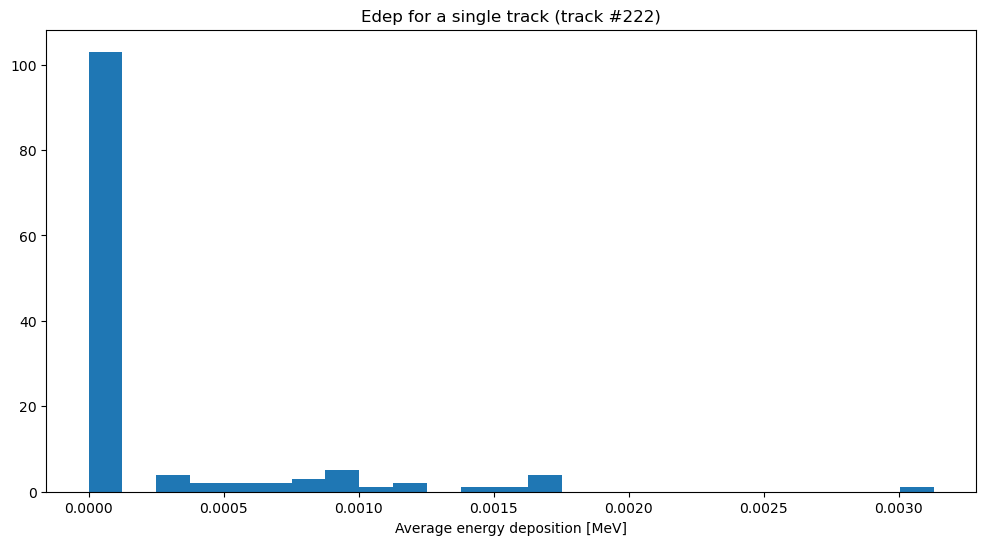

In [30]:
plt.figure(figsize=(12,6))
plt.hist(single_energies, bins=25)
plt.xlabel("Average energy deposition [MeV]")
plt.title(f"Edep for a single track (track #{ran_num})")

## Superlayer Edep

### Import data

In [7]:
# Get gas sublayer with wires data 
superlayer_df = pd.read_csv(f'csv/superlayers/layered_edep_data.csv')
superlayer_df = organize_df(superlayer_df, ["entry_x", "entry_y", "entry_z", "exit_x", "exit_y", "exit_z", "edep"])

# Get gas sublayer without wires data 
nowires_superlayer_df = pd.read_csv(f'csv/superlayers/layered_edep_data_nowires.csv')
nowires_superlayer_df = organize_df(nowires_superlayer_df, ["entry_x", "entry_y", "entry_z", "exit_x", "exit_y", "exit_z", "edep"])

# Get radii of gas layers
superlayer_radii_df = pd.read_csv(f'csv/superlayers/layer_radius.csv')
print(len(superlayer_radii_df))

# Get multiple scattering data
superlayer_eepos_df = pd.read_csv(f'csv/superlayers/entry_exit_data.csv')
nowires_superlayer_eepos_df = pd.read_csv(f'csv/superlayers/entry_exit_data_nowires.csv')
layer_eepos_df = pd.read_csv(f'csv/layered/entry_exit_data.csv')

55


### 2D circular edep

_____________ Wire Material Included in Gas Mixture _____________


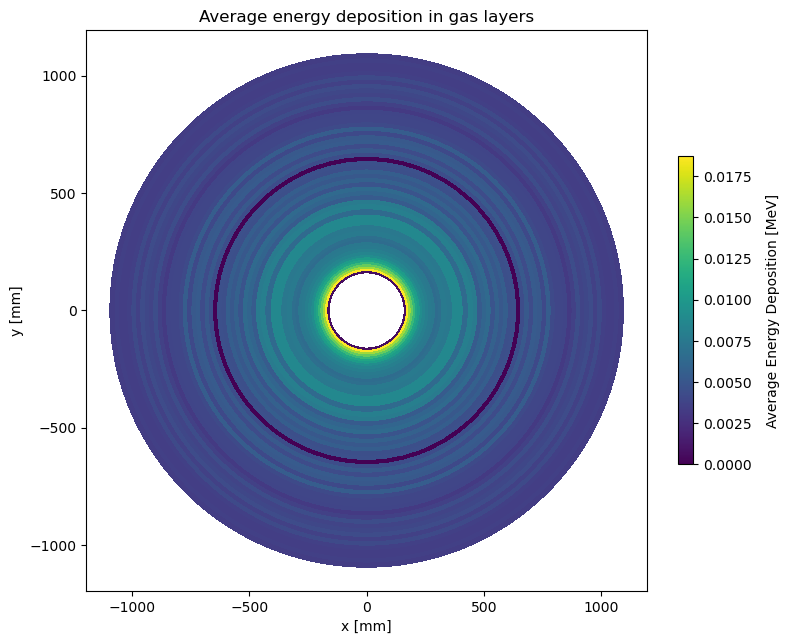

In [78]:
print("_____________ Wire Material Included in Gas Mixture _____________")
energies_wires = plot_layer_overview(superlayer_radii_df, superlayer_df, [])
#plot_edep_layer_overview(superlayer_df)

_____________ NO Wire Material Included in Gas Mixture _____________


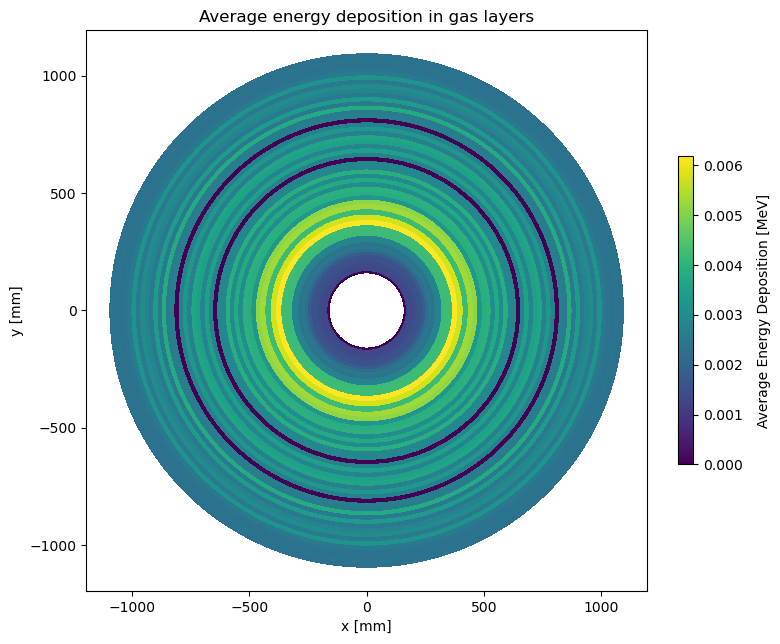

In [82]:
print("_____________ NO Wire Material Included in Gas Mixture _____________")
energies_nowires = plot_layer_overview(superlayer_radii_df, nowires_superlayer_df, [])
#plot_edep_layer_overview(nowires_superlayer_df)

### Average edep histograms

Text(0.5, 1.0, 'Edep for superlayers without wire mixture included')

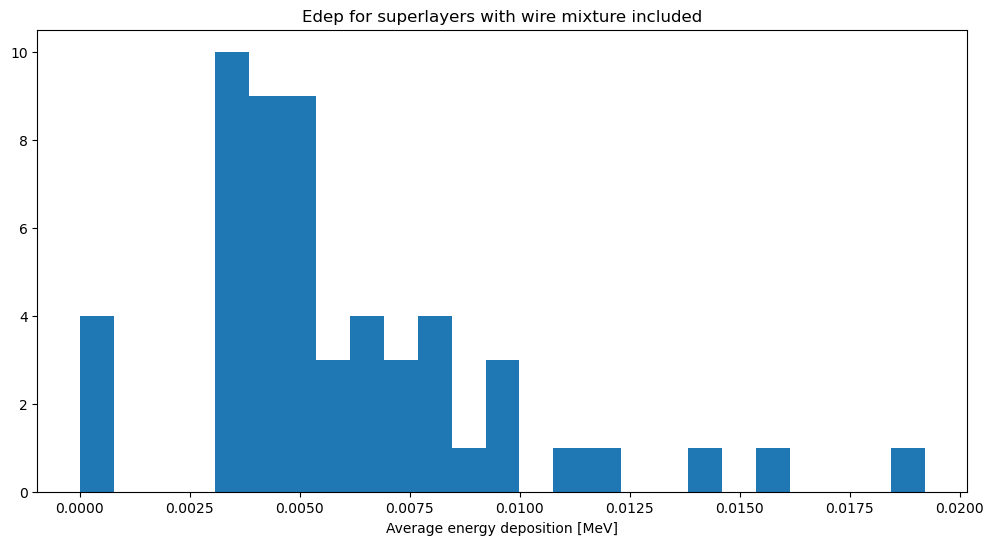

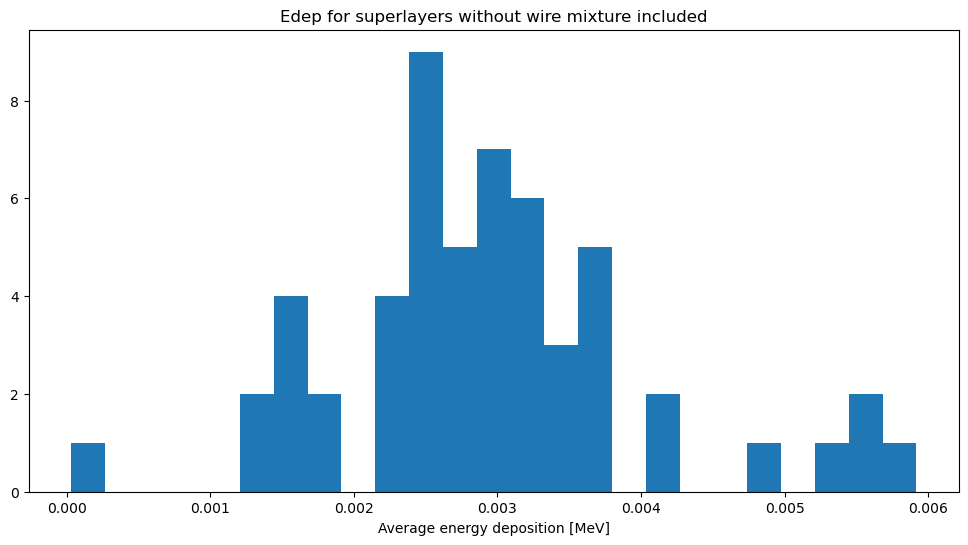

In [38]:
plt.figure(figsize=(12,6))
plt.hist(energies_wires, bins=25)
plt.xlabel("Average energy deposition [MeV]")
plt.title(f"Edep for superlayers with wire mixture included")

plt.figure(figsize=(12,6))
plt.hist(energies_nowires, bins=25)
plt.xlabel("Average energy deposition [MeV]")
plt.title(f"Edep for superlayers without wire mixture included")

## Tracks and Multiple Scattering

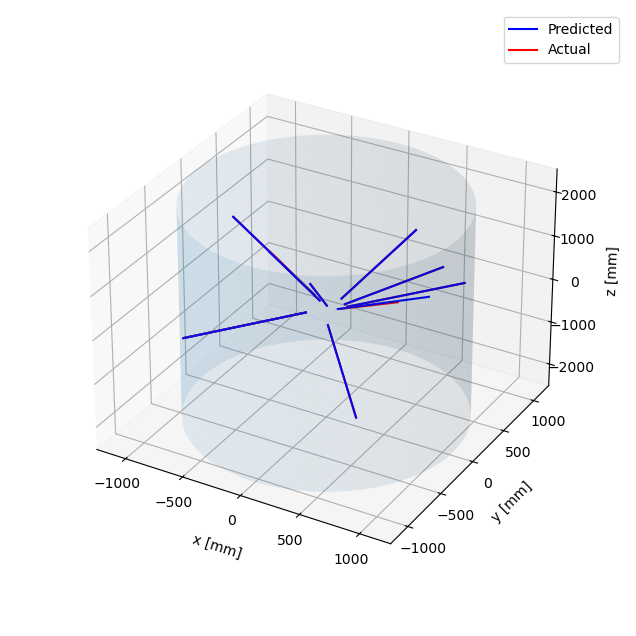

In [40]:
def plot_act_and_pred(df, n):
    '''Plot a linear version of the first n tracks using their start and end points'''
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(0, n):
        ran_num = random.randint(0, len(df) - 1)
        curdf = df.loc[ran_num]
    
        ax.plot3D([curdf["actx_ent"], curdf["actx_exit"]], \
                  [curdf["acty_ent"], curdf["acty_exit"]], \
                  [curdf["actz_ent"], curdf["actz_exit"]], 'red')

        ax.plot3D([curdf["predx_ent"], curdf["predx_exit"]], \
                      [curdf["predy_ent"], curdf["predy_exit"]], \
                      [curdf["predz_ent"], curdf["predz_exit"]], 'blue')
    
    ax.set_xlabel('x [mm]', labelpad=10)
    ax.set_ylabel('y [mm]', labelpad=10)
    ax.set_zlabel('z [mm]', labelpad=10)

    # Add legend
    blue_line = Line2D([1, 4], [2, 5], color='blue', label="Predicted")
    red_line = Line2D([1, 4], [2, 5], color='red', label="Actual")
    plt.legend(handles=[blue_line, red_line])

    # Choose angle to view
    #ax.view_init(elev=0, azim=90)
    
num_to_plot = 10
plot_act_and_pred(eepos_df, num_to_plot)

### Average scattering

Average distance of entrance scattering = 30.6426 mm


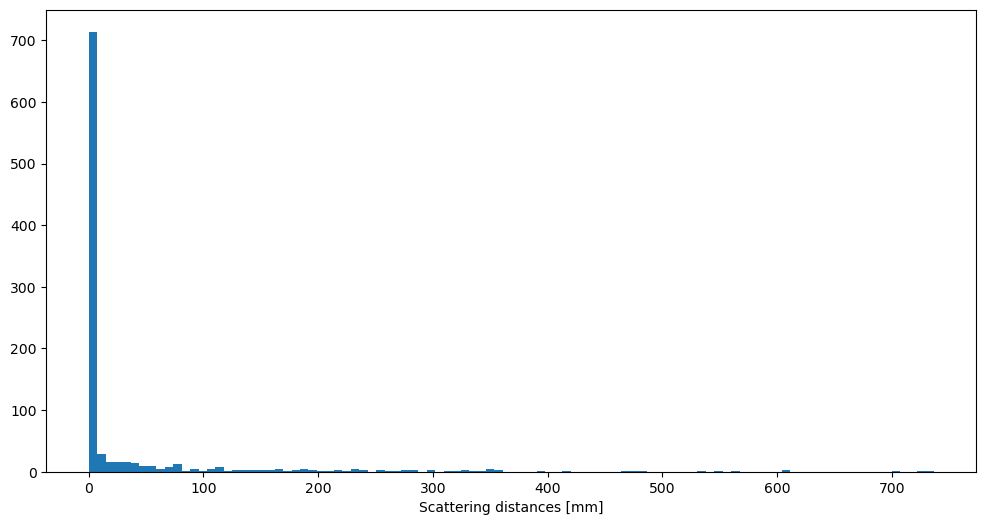

In [42]:
def get_avg_scattering(df):
    sum_dist = 0
    count = 0

    distances = []
    
    for i in range(0, len(df)):
        curdf = df.loc[i]
        
        if curdf["actx_ent"] == curdf["actx_exit"] \
        or curdf["acty_ent"] == curdf["acty_exit"] \
        or curdf["actz_ent"] == curdf["actz_exit"]: continue
        
        dist = np.sqrt( (curdf["actx_ent"]-curdf["predx_ent"])**2 +\
                             (curdf["acty_ent"]-curdf["predy_ent"])**2 +\
                             (curdf["actz_ent"]-curdf["predz_ent"])**2 )
        sum_dist += dist
        distances.append(dist)
        
        count += 1

    sum_dist /= count
    print(f'Average distance of entrance scattering = {sum_dist:.4f} mm')

    plt.figure(figsize=(12,6))
    plt.hist(distances, bins=100)
    plt.xlabel("Scattering distances [mm]")

get_avg_scattering(eepos_df)

### Scattering in layered volumes

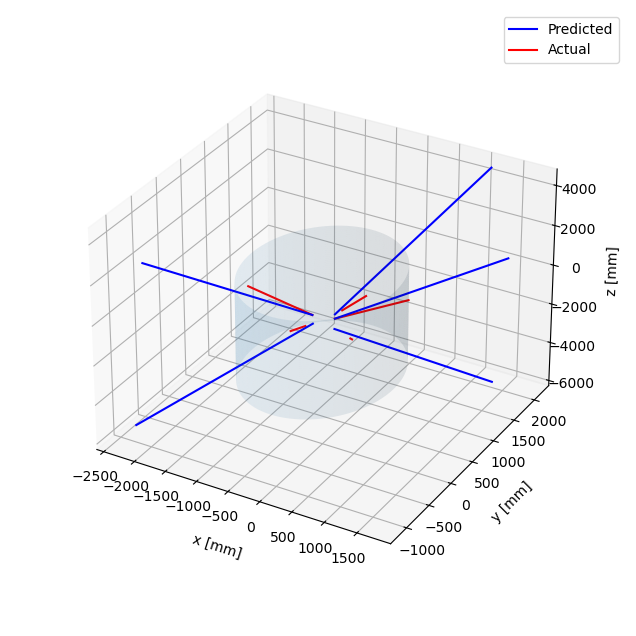

In [44]:
plot_act_and_pred(superlayer_eepos_df, 5)

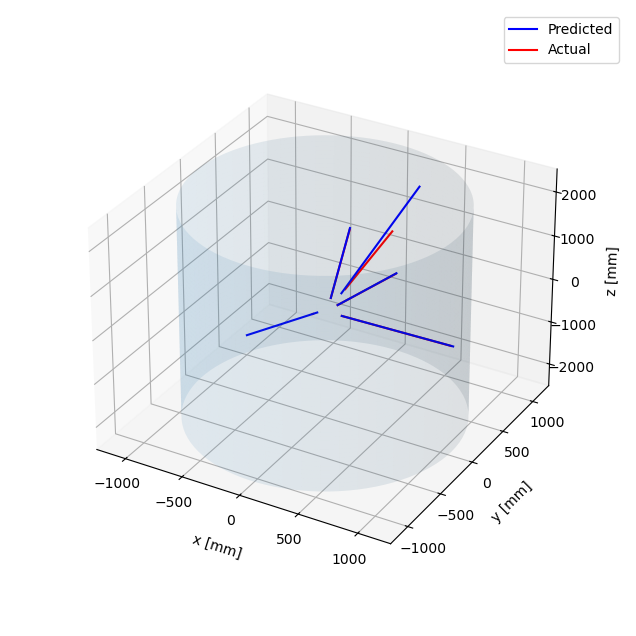

In [45]:
plot_act_and_pred(nowires_superlayer_eepos_df, 5)
#get_avg_scattering(nowires_superlayer_eepos_df)

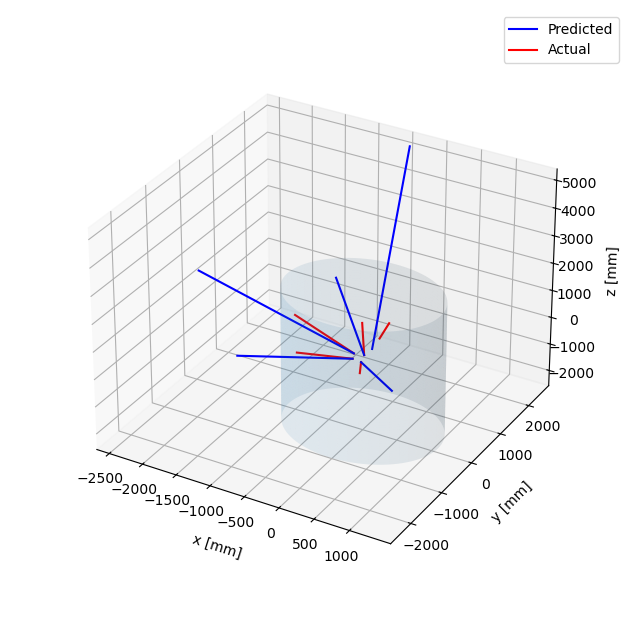

In [46]:
plot_act_and_pred(layer_eepos_df, 5)
#get_avg_scattering(layer_eepos_df)

## $\chi^2$ and ndf

Text(0.5, 0, 'chi2')

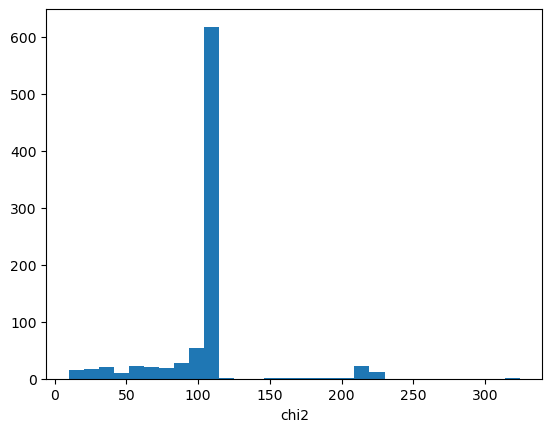

In [204]:
chi2_df = pd.read_csv(f'csv/chi2.csv')
plt.hist(chi2_df["chi2"], bins=30)
plt.xlabel("chi2")

Text(0.5, 0, 'ndf')

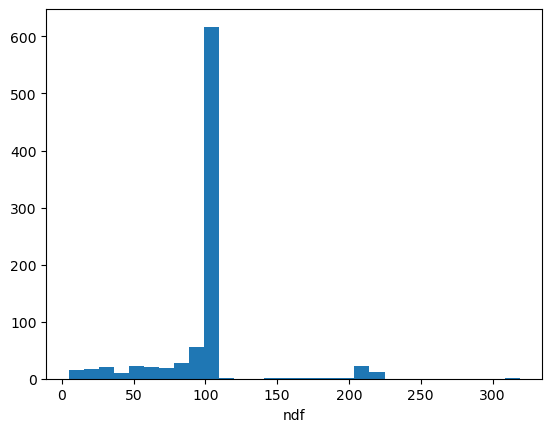

In [206]:
plt.hist(chi2_df["ndf"], bins=30)
plt.xlabel("ndf")

Text(0.5, 0, 'p-value')

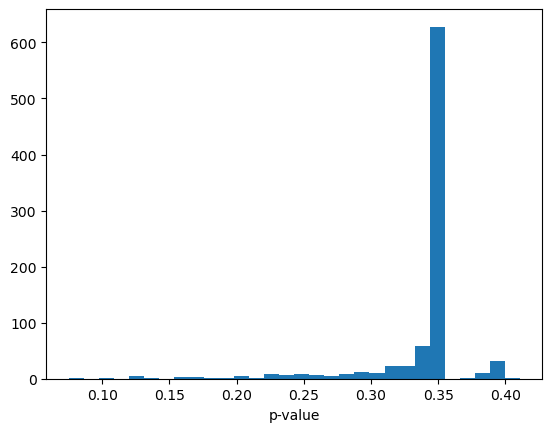

In [208]:
p_value = chi2.sf(chi2_df['chi2'], chi2_df['ndf'])
plt.hist(p_value, bins=30)
plt.xlabel("p-value")

Text(0, 0.5, '$\\chi^2$')

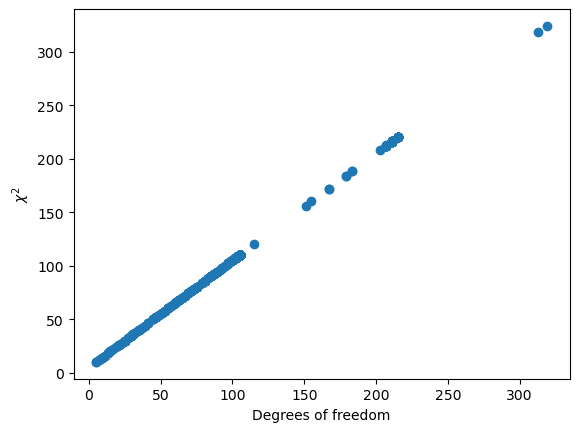

In [200]:
plt.scatter(chi2_df["ndf"], chi2_df["chi2"])
plt.xlabel("Degrees of freedom")
plt.ylabel("$\\chi^2$")

## Other

In [419]:
with uproot.open("root/kalman_output.root") as file:
    tree = file["Particles"]
    df = tree.arrays(["KalmanFitted/KalmanFitted.hitPos.fCoordinates.fX", \
                      "KalmanFitted/KalmanFitted.hitPos.fCoordinates.fY", \
                      "KalmanFitted/KalmanFitted.hitPos.fCoordinates.fZ", \
                      
                      "Actual/Actual.entryPos.fCoordinates.fX", \
                      "Actual/Actual.entryPos.fCoordinates.fY", \
                      "Actual/Actual.entryPos.fCoordinates.fZ",\
                      
                      "KalmanFitted/KalmanFitted.hitMom.fCoordinates.fX",\
                      "KalmanFitted/KalmanFitted.hitMom.fCoordinates.fY",\
                      "KalmanFitted/KalmanFitted.hitMom.fCoordinates.fZ",\

                      "Actual/Actual.initMom.fCoordinates.fX",\
                      "Actual/Actual.initMom.fCoordinates.fY",\
                      "Actual/Actual.initMom.fCoordinates.fZ",\
                      
                      "KalmanFitted/KalmanFitted.trackID",\
                      "Actual/Actual.trackID"], library="pd")

row = df.iloc[0]

### Fitting

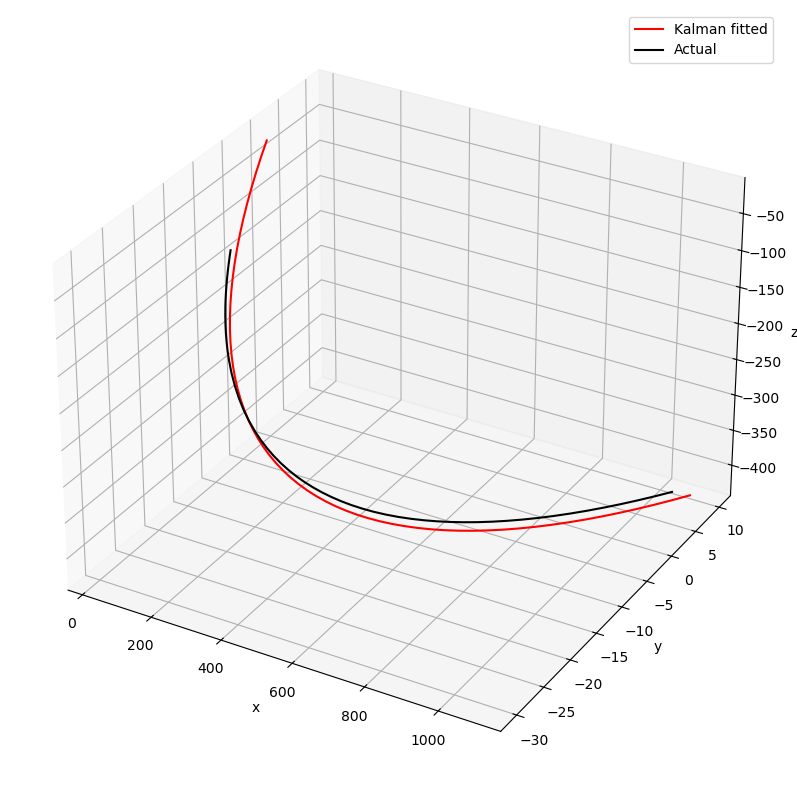

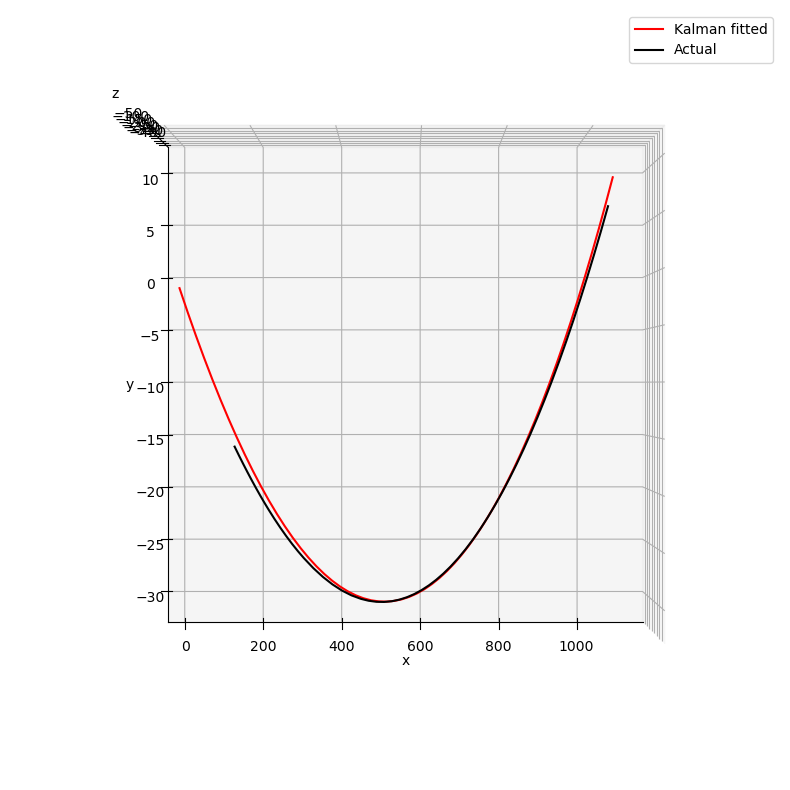

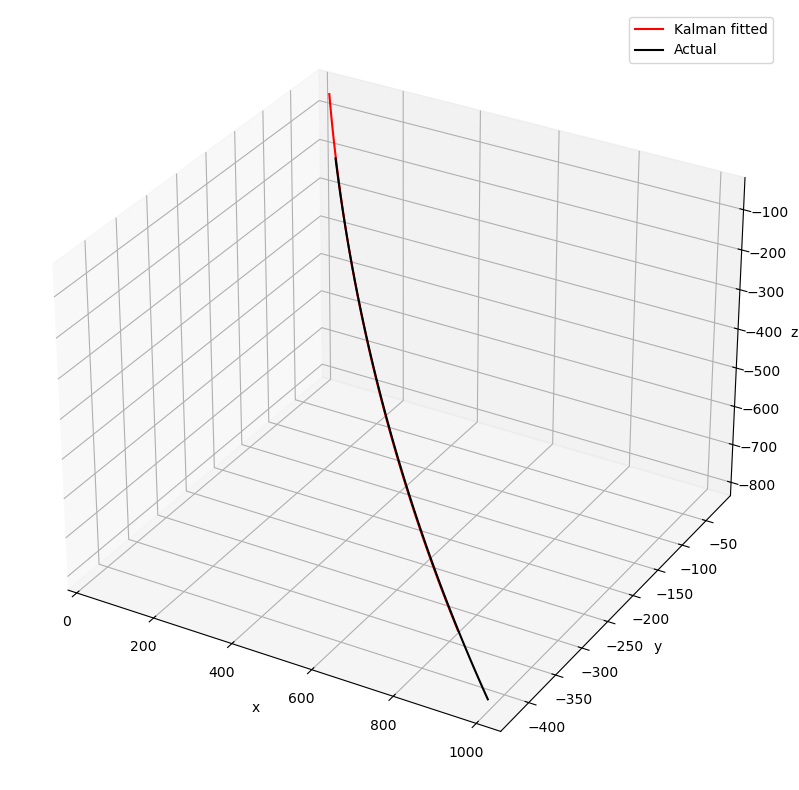

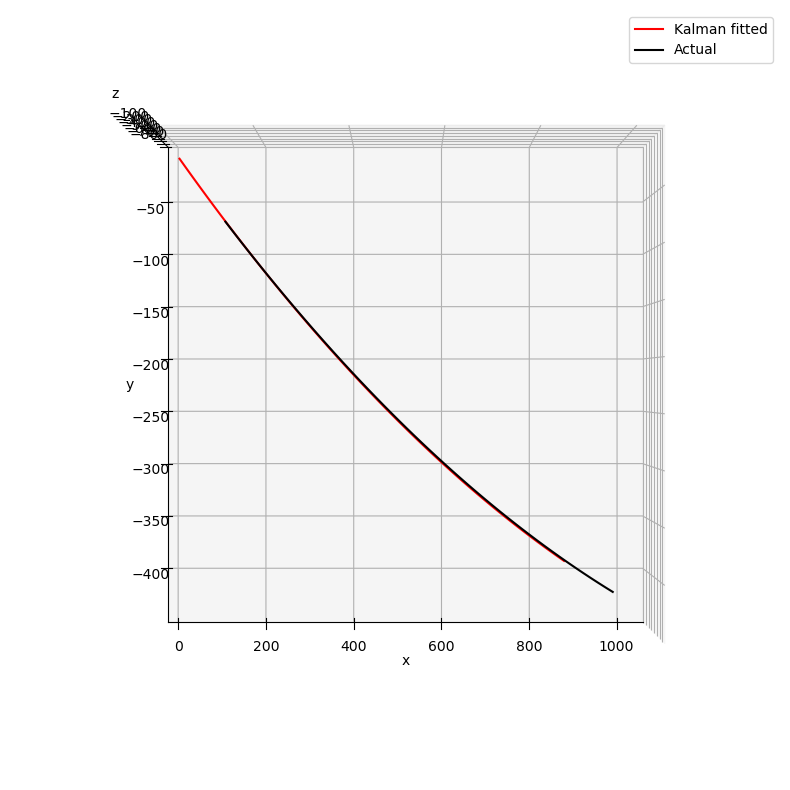

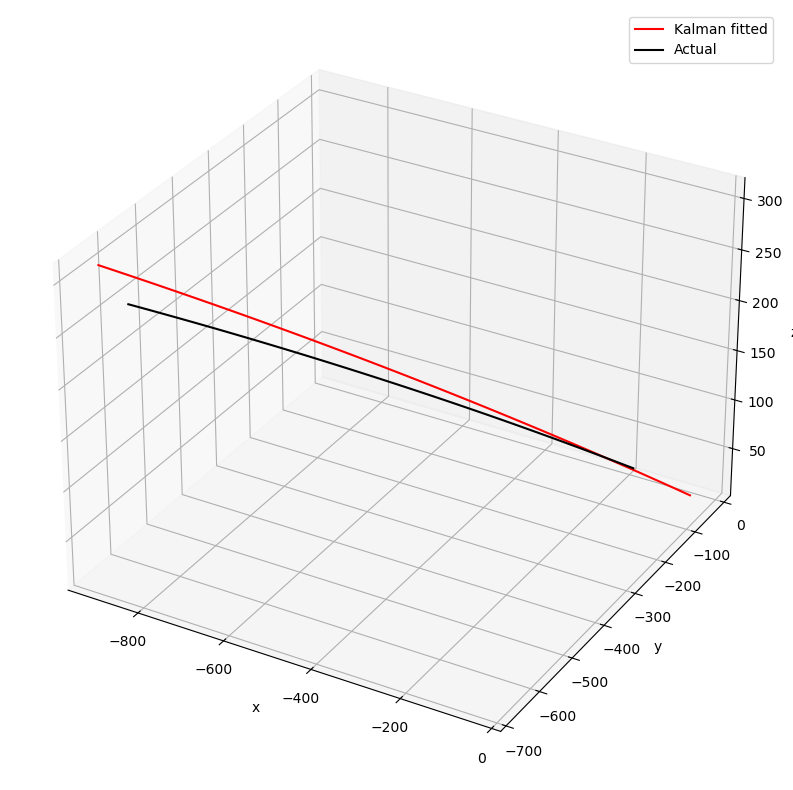

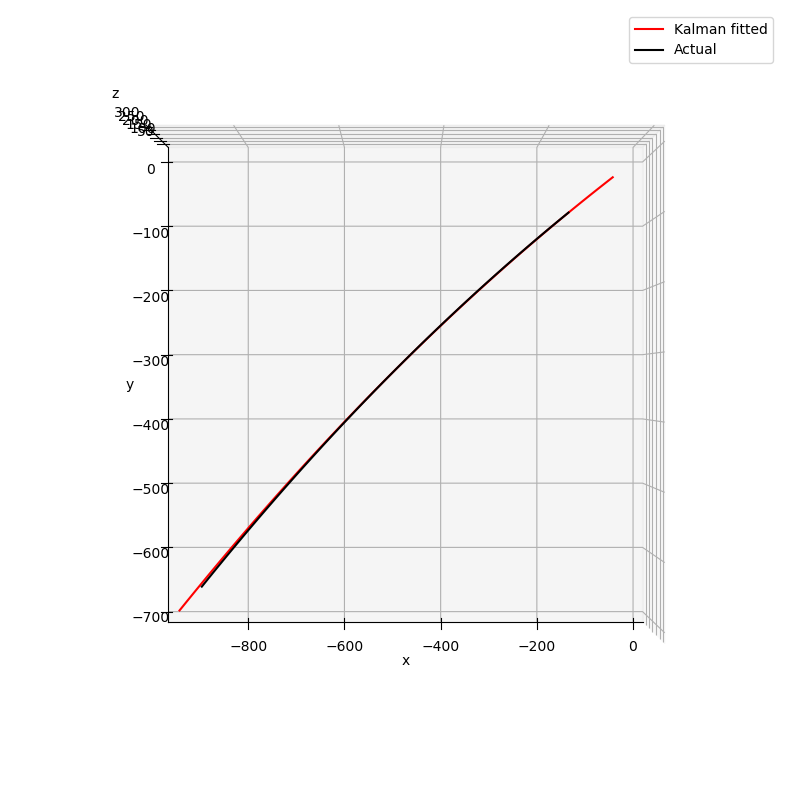

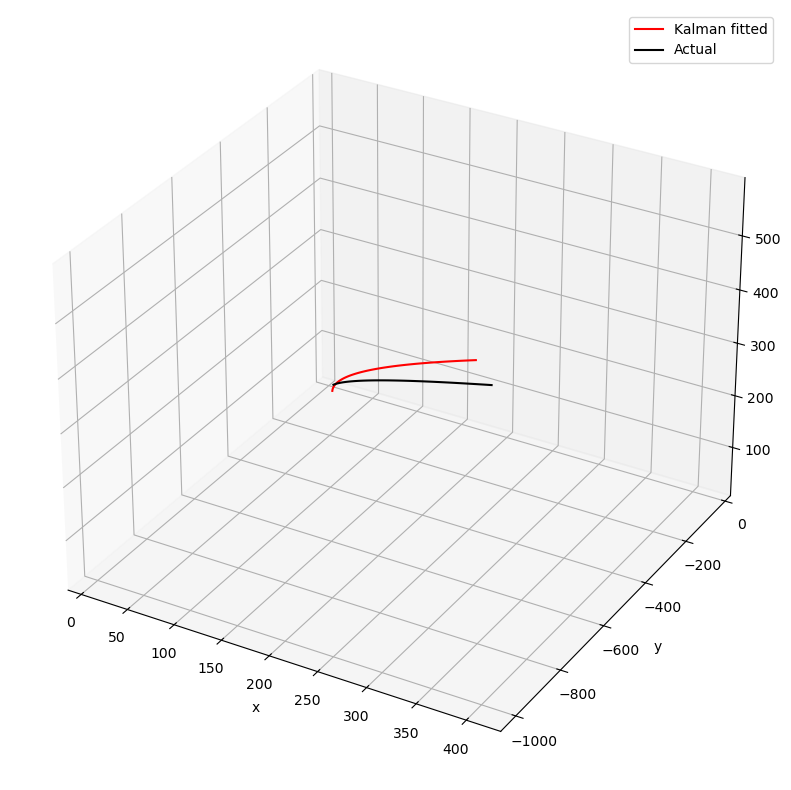

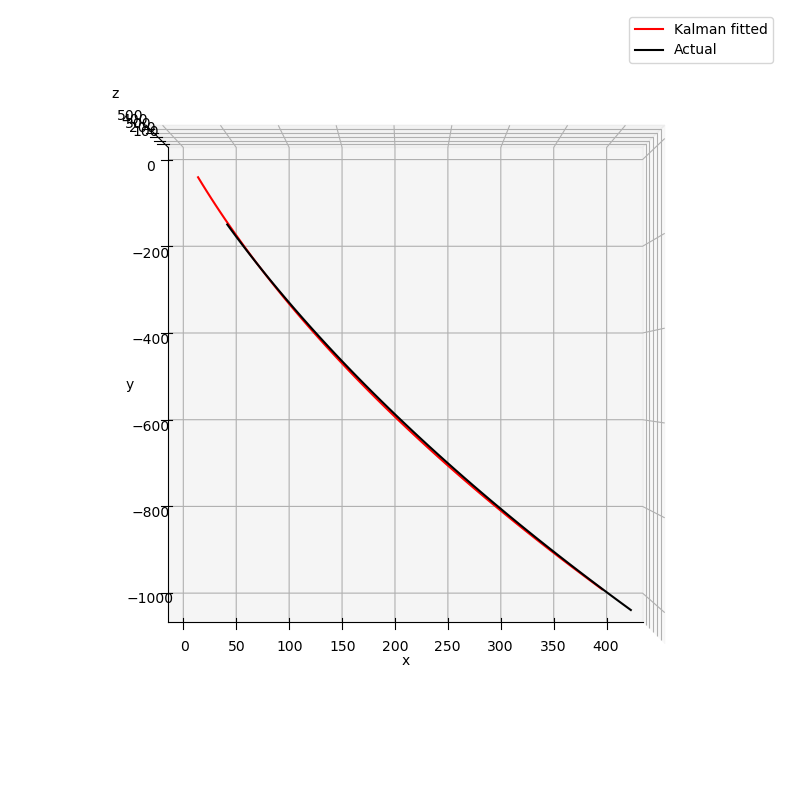

In [427]:
def plot_fit(track, sideView):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(projection='3d')

    kalman_data = [[],[],[]]
    actual_data = [[],[],[]]

    for i in range(len(row['KalmanFitted/KalmanFitted.trackID'])):
        if row['KalmanFitted/KalmanFitted.trackID'][i] == track:
            kalman_data[0].append(row["KalmanFitted/KalmanFitted.hitPos.fCoordinates.fX"][i])
            kalman_data[1].append(row["KalmanFitted/KalmanFitted.hitPos.fCoordinates.fY"][i])
            kalman_data[2].append(row["KalmanFitted/KalmanFitted.hitPos.fCoordinates.fZ"][i])
        try:
            if row['Actual/Actual.trackID'][i] == track:
                actual_data[0].append(row["Actual/Actual.entryPos.fCoordinates.fX"][i])
                actual_data[1].append(row["Actual/Actual.entryPos.fCoordinates.fY"][i])
                actual_data[2].append(row["Actual/Actual.entryPos.fCoordinates.fZ"][i])
        except:
            continue

    ax.plot(kalman_data[0], kalman_data[1], kalman_data[2], color="red", label="Kalman fitted")
    ax.plot(actual_data[0], actual_data[1], actual_data[2], color="black", label="Actual")

    if sideView:
        ax.view_init(elev=90, azim=-90)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    plt.legend()

plot_fit(2, False)
plot_fit(2, True)
plot_fit(3, False)
plot_fit(3, True)
plot_fit(4, False)
plot_fit(4, True)
plot_fit(7, False)
plot_fit(7, True)

### Momentum

In [343]:
def plot_momentum(track):
    #plt.figure(figsize=(12,10))

    mom_kalman = []
    mom_actual = []

    for i in range(len(row['KalmanFitted/KalmanFitted.trackID'])):
        if row['KalmanFitted/KalmanFitted.trackID'][i] == track:
            x = row["KalmanFitted/KalmanFitted.hitMom.fCoordinates.fX"][i]
            y = row["KalmanFitted/KalmanFitted.hitMom.fCoordinates.fY"][i]
            z = row["KalmanFitted/KalmanFitted.hitMom.fCoordinates.fZ"][i]
            mom_kalman.append(np.sqrt(x**2 + y**2 + z**2) -2002)
    
    for i in range(len(row["Actual/Actual.trackID"])):
        if row["Actual/Actual.trackID"][i] == track:
            x = row["Actual/Actual.initMom.fCoordinates.fX"][i]
            y = row["Actual/Actual.initMom.fCoordinates.fY"][i]
            z = row["Actual/Actual.initMom.fCoordinates.fZ"][i]
            mom_actual.append(np.sqrt(x**2 + y**2 + z**2)-2002)

    print(f'___________ KALMAN (-2002) _____________\n{mom_kalman}\n')
    print(f'___________ ACTUAL (-2002) _____________\n{mom_actual}\n')

    #plt.hist(mom_actual, label="Actual", bins=30)
    #plt.hist(mom_kalman, color="red", label="Kalman fitted", bins=30)

    #plt.xlabel("momentum")
    #plt.legend()

plot_momentum(track)

___________ KALMAN (-2002) _____________
[3.827137897698776, 3.8271378976990036, 3.827137897698776, 3.8271378976990036, 3.8271378976990036, 3.827137897699231, 3.8271378976990036, 3.8271378976994583, 3.827137897699231, 3.8271378976994583, 3.827137897699231, 3.8271378976994583, 3.827137897699231, 3.8271378976990036, 3.8271378976990036, 3.8271378976990036, 3.8271378976990036, 3.8271378976990036, 3.827137897699231, 3.827137897699231, 3.8271378976990036, 3.8271378976994583, 3.8271378976990036, 3.8271378976990036, 3.827137897699231, 3.827137897699231, 3.8271378976990036, 3.827137897699231, 3.8271378976990036, 3.827137897699231, 3.8271378976994583, 3.8271378976990036, 3.827137897699231, 3.8271378976990036, 3.827137897699231, 3.827137897698776, 3.827137897699231, 3.827137897699231, 3.8271378976990036, 3.8271378976990036, 3.827137897699231, 3.8271378976990036, 3.8271378976990036, 3.827137897699231, 3.827137897699231, 3.827137897698776, 3.8271378976990036, 3.8271378976994583, 3.827137897699231, 

## Signal

In [440]:
clusters_df = pd.read_csv(f'csv/clusterInfo.csv')
clusters_df["hit_time"] = clusters_df["gen_time"] + clusters_df["drift_time"]

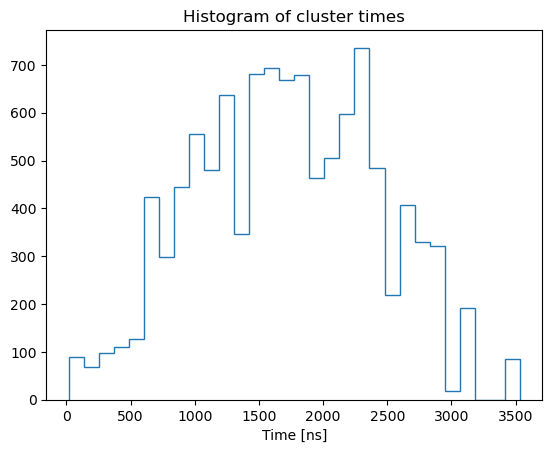

In [506]:
plt.hist(clusters_df["hit_time"], bins=30, histtype='step')
plt.title("Histogram of cluster times")
plt.xlabel("Time [ns]")
plt.show()

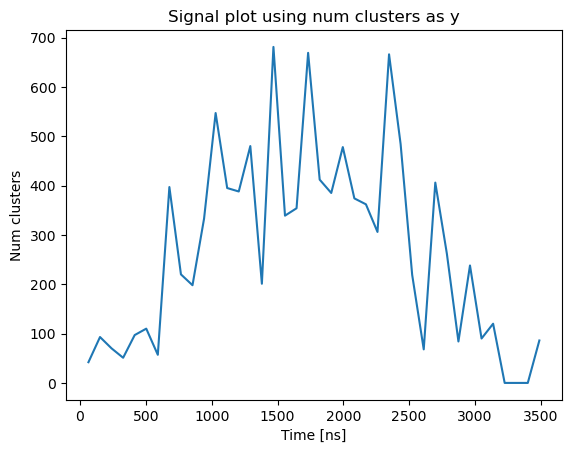

In [510]:
counts, bin_edges = np.histogram(clusters_df["hit_time"], bins=40)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_centers, counts)
plt.xlabel("Time [ns]")
plt.ylabel("Num clusters")
plt.title("Signal plot using num clusters as y")
plt.show()

In [502]:
electrons = {}
count = 0

with open("test.txt", "r") as f:
    for line in f:
        cur_electron = int(line.strip("\n"))
        if not cur_electron in electrons.keys():
            electrons[cur_electron] = 0
         
        electrons[cur_electron] += 1  
        count += 1

electrons = dict(sorted(electrons.items()))

ranges = []

for i in range(1, 31):
    ranges.append({"min": i, "max": i, "weight": electrons[i]/count})

cur_count = 31
while cur_count < 200:
    tot_sum = 0
    for i in range(cur_count, cur_count+10):
        if i in electrons:
            tot_sum += electrons[i]
    if tot_sum > 0:
        ranges.append({"min": cur_count, "max": cur_count+9, "weight": tot_sum/count})
    cur_count += 10

def get_weighted_range_number(ranges):
    weights = [r["weight"] for r in ranges]
    selected_range = random.choices(ranges, weights=weights, k=1)[0]
    return random.randint(selected_range["min"], selected_range["max"])

Text(0.5, 1.0, 'Signal plot using ran num electrons as y')

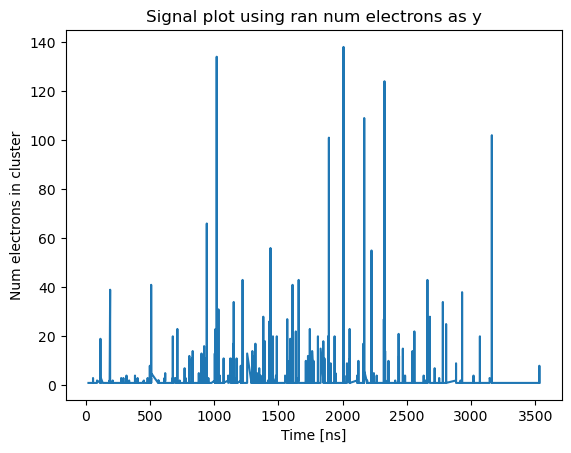

In [514]:
clusters_df.sort_values(by="hit_time", inplace=True)

count_list = []
for i in range(len(clusters_df["hit_time"])):
    count_list.append(get_weighted_range_number(ranges))

plt.plot(clusters_df["hit_time"], count_list)
plt.xlabel("Time [ns]")
plt.ylabel("Num electrons in cluster")
plt.title("Signal plot using ran num electrons as y")

long_sigma = 1.27836400568038e-06
trans_sigma = 1.930683566874576e-05
quad_sigma = 1.7265808251708233e-05

long_ran = -1.8734772359028854e-07
trans_ran = 1.5895045235790397e-05
quad_ran = -1.800783629040555e-06

sample_t = 2679.3636819000003
smeared_t_long = 2679.3636817126526
smeared_t_trans = 2679.3636977950455
smeared_t_quad = 2679.3636800992167



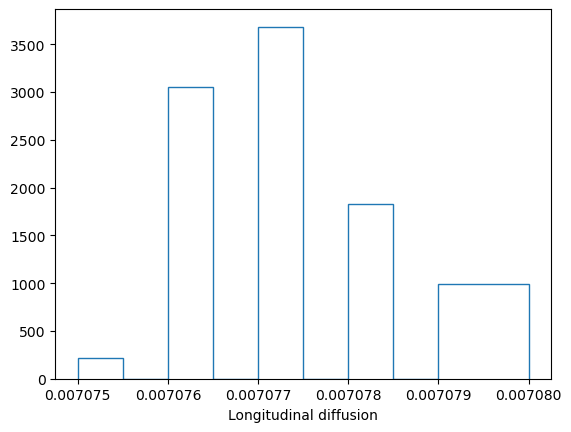

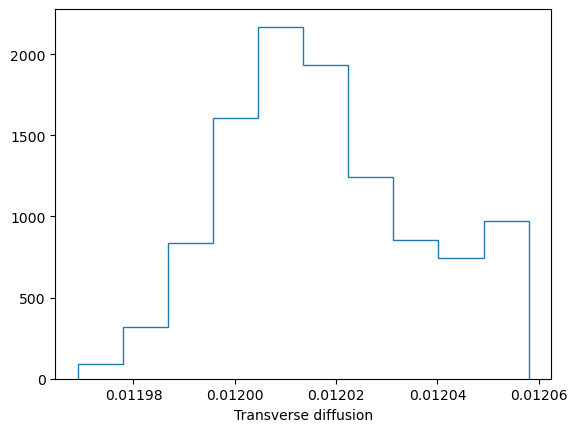

In [534]:
# Get stdev of diffusion values
long_sigma = np.std(clusters_df["long_diffusion"], ddof=1)
trans_sigma = np.std(clusters_df["trans_diffusion"], ddof=1)
quad_sigma = np.std(np.sqrt(clusters_df["long_diffusion"]**2 + clusters_df["trans_diffusion"]**2), ddof=1)
print(f'long_sigma = {long_sigma}')
print(f'trans_sigma = {trans_sigma}')
print(f'quad_sigma = {quad_sigma}\n')

# Generate a random time based on that sigma
long_ran = random.gauss(0, long_sigma)
trans_ran = random.gauss(0, trans_sigma)
quad_ran = random.gauss(0, quad_sigma)
print(f'long_ran = {long_ran}')
print(f'trans_ran = {trans_ran}')
print(f'quad_ran = {quad_ran}\n')

# Sample to test
sample_time = clusters_df["hit_time"][0]
print(f'sample_t = {sample_time}')

# Smear the sample time by adding the random time
print(f'smeared_t_long = {sample_time + long_ran}')
print(f'smeared_t_trans = {sample_time + trans_ran}')
print(f'smeared_t_quad = {sample_time + quad_ran}\n')

# Plot hists of diffusion constants to check if Gaussian
plt.hist(clusters_df["long_diffusion"], bins=10, histtype='step')
plt.xlabel("Longitudinal diffusion")
plt.show()
plt.hist(clusters_df["trans_diffusion"], bins=10, histtype='step')
plt.xlabel("Transverse diffusion")
plt.show()